# Stereo Panning

**Equal-power panning** places a mono signal at any position in the stereo field while maintaining constant total power:

`L = cos(θ) · signal,  R = sin(θ) · signal`

where `θ = (pan + 1) · π/4` maps pan ∈ [−1, +1] to the quarter-circle [0, π/2].  At centre (pan = 0): L = R = 1/√2, so each channel carries half the power and the total power equals the mono source.

**M/S stereo widening** encodes L/R into mid (M = L+R) and side (S = L−R) components, scales S by a width factor, then decodes back. Width = 0 collapses to mono; width = 1 is unchanged; width > 1 exaggerates the stereo image.

| Function | Description |
| --- | --- |
| `pan` | Equal-power stereo panning. `position` ∈ [−1, +1]: −1 = full left, 0 = centre, +1 = full right. |
| `stereo_widen` | M/S stereo widening. `width` = 0 → mono, 1 → original stereo, 2 → exaggerated width. |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.generators import generate_sine
from python.spatial import pan, stereo_widen

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

Equal-power panning and stereo widening on a 440 Hz mono sine (3 cycles).

**2 × 3 grid:**

**Top row — panning:**
- **Top-left — pan law curves:** L/R gain (amplitude) plotted vs pan position [−1, +1]; gain curves cross at 1/√2 (−3 dB) at centre, guaranteeing constant power at all positions; L reaches 0 at pan = +1, R reaches 0 at pan = −1
- **Top-centre — panned waveforms:** five pan positions (−1 / −0.5 / 0 / 0.5 / +1); amplitude in each channel follows the cos/sin law from the curve above
- **Top-right — L vs R scatter plot:** each point is one sample; the angle of the scatter relative to the axes shows the pan position

**Bottom row — stereo widening (starting from a centre-panned stereo signal):**
- **Width = 0:** pure mono; L = R = M/2; side channel is silent
- **Width = 1:** original stereo unchanged; mid and side balance preserved
- **Width = 2:** side channel doubled; left and right diverge further; can cause phase issues on mono summing


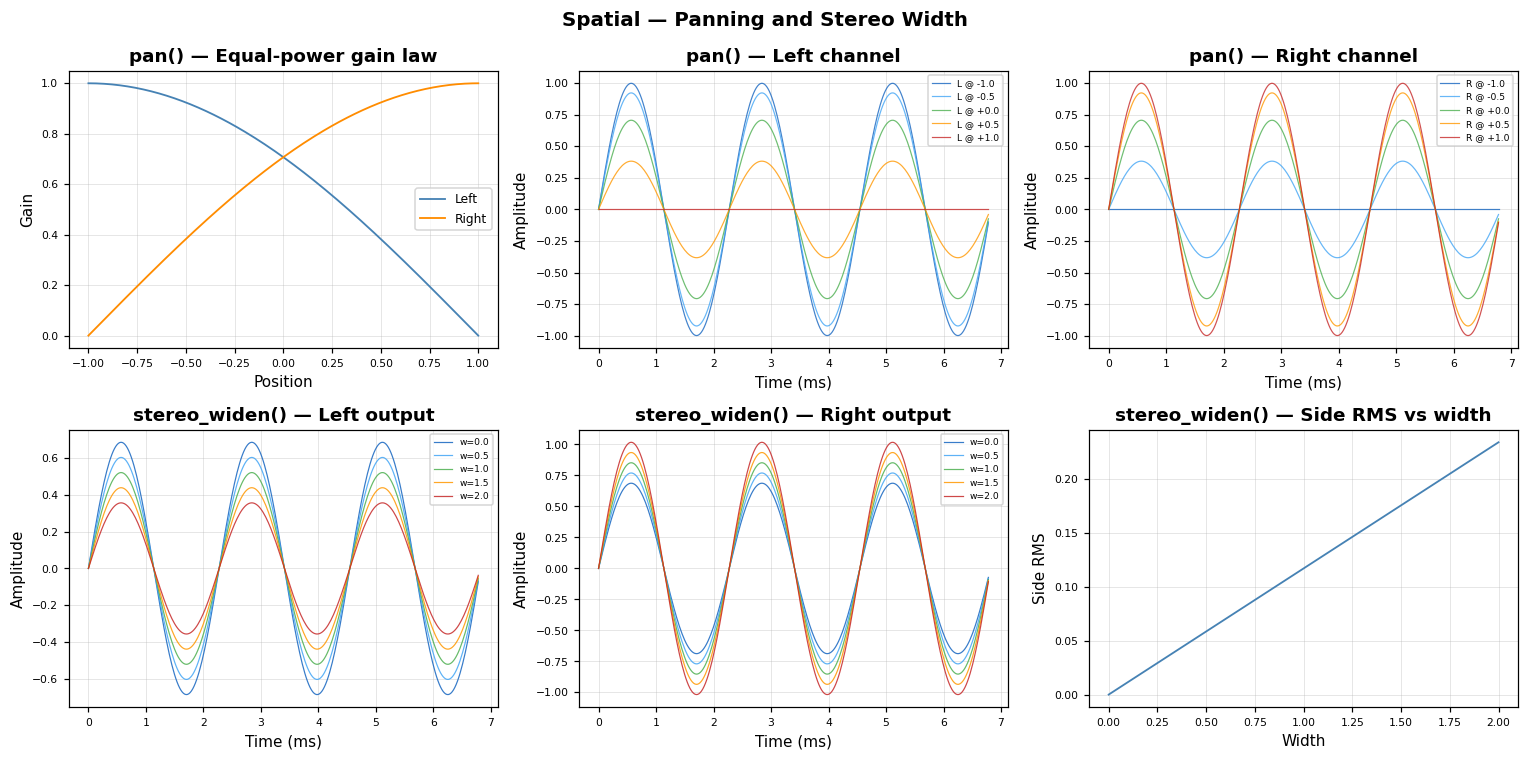

In [2]:
FS = 44100
FREQ = 440.0
DURATION = 3 / FREQ

_, mono = generate_sine(freq=FREQ, fs=FS, duration=DURATION)
t_ms = np.arange(len(mono)) / FS * 1000

POSITIONS = [-1.0, -0.5, 0.0, 0.5, 1.0]
COLORS = ["#1565c0", "#42a5f5", "#4caf50", "#ff9800", "#c62828"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

# pan: L/R amplitudes vs position
pos_range = np.linspace(-1, 1, 200)
theta = (pos_range + 1) * np.pi / 4
L_gain = np.cos(theta)
R_gain = np.sin(theta)
axes[0, 0].plot(pos_range, L_gain, color="steelblue", linewidth=1.2, label="Left")
axes[0, 0].plot(pos_range, R_gain, color="darkorange", linewidth=1.2, label="Right")
axes[0, 0].set_title("pan() — Equal-power gain law", fontweight="bold")
axes[0, 0].set_xlabel("Position")
axes[0, 0].set_ylabel("Gain")
axes[0, 0].legend(fontsize=8)

# pan: waveforms at each position
for pos, color in zip(POSITIONS, COLORS):
    L, R = pan(mono, position=pos)
    axes[0, 1].plot(t_ms, L, linewidth=0.8, color=color, label=f"L @ {pos:+.1f}", alpha=0.8)
axes[0, 1].set_title("pan() — Left channel", fontweight="bold")
axes[0, 1].set_xlabel("Time (ms)")
axes[0, 1].set_ylabel("Amplitude")
axes[0, 1].legend(fontsize=6)

for pos, color in zip(POSITIONS, COLORS):
    L, R = pan(mono, position=pos)
    axes[0, 2].plot(t_ms, R, linewidth=0.8, color=color, label=f"R @ {pos:+.1f}", alpha=0.8)
axes[0, 2].set_title("pan() — Right channel", fontweight="bold")
axes[0, 2].set_xlabel("Time (ms)")
axes[0, 2].set_ylabel("Amplitude")
axes[0, 2].legend(fontsize=6)

# stereo_widen: start with a panned stereo pair
L_in, R_in = pan(mono, position=0.3)
WIDTHS = [0.0, 0.5, 1.0, 1.5, 2.0]
W_COLORS = ["#1565c0", "#42a5f5", "#4caf50", "#ff9800", "#c62828"]

for width, color in zip(WIDTHS, W_COLORS):
    L_w, R_w = stereo_widen(L_in, R_in, width=width)
    axes[1, 0].plot(t_ms, L_w, linewidth=0.8, color=color, label=f"w={width}", alpha=0.85)
axes[1, 0].set_title("stereo_widen() — Left output", fontweight="bold")
axes[1, 0].set_xlabel("Time (ms)")
axes[1, 0].set_ylabel("Amplitude")
axes[1, 0].legend(fontsize=6)

for width, color in zip(WIDTHS, W_COLORS):
    L_w, R_w = stereo_widen(L_in, R_in, width=width)
    axes[1, 1].plot(t_ms, R_w, linewidth=0.8, color=color, label=f"w={width}", alpha=0.85)
axes[1, 1].set_title("stereo_widen() — Right output", fontweight="bold")
axes[1, 1].set_xlabel("Time (ms)")
axes[1, 1].set_ylabel("Amplitude")
axes[1, 1].legend(fontsize=6)

# Side level vs width
side_rms = []
for w in np.linspace(0, 2, 100):
    _, R_w = stereo_widen(L_in, R_in, width=w)
    L_w, _ = stereo_widen(L_in, R_in, width=w)
    side = (L_w - R_w) * 0.5
    side_rms.append(np.sqrt(np.mean(side ** 2)))
axes[1, 2].plot(np.linspace(0, 2, 100), side_rms, color="steelblue", linewidth=1.2)
axes[1, 2].set_title("stereo_widen() — Side RMS vs width", fontweight="bold")
axes[1, 2].set_xlabel("Width")
axes[1, 2].set_ylabel("Side RMS")

for ax in axes.flatten():
    ax.tick_params(labelsize=7)
    ax.grid(True, linewidth=0.4, alpha=0.5)

fig.suptitle("Spatial — Panning and Stereo Width", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Audio Examples

Equal-power panning and M/S widening are purely perceptual — use headphones for the full stereo effect.

| Example | Stereo image |
| --- | --- |
| Hard left | Signal only on left channel |
| Center | Equal power in both channels |
| Hard right | Signal only on right channel |
| Widened | L/R pair spread wider than the speakers |


In [ ]:
from IPython.display import Audio, display

DUR_A     = 2.0
_, mono_a = generate_sine(freq=440.0, fs=FS, duration=DUR_A)

L_l, R_l = pan(mono_a, position=-1.0)
L_c, R_c = pan(mono_a, position=0.0)
L_r, R_r = pan(mono_a, position=1.0)
# Widen a natural L/R pair
L_w, R_w = stereo_widen(L_l, R_r, width=2.0)

def ns(L, R):  # normalise stereo pair
    pk = np.max(np.abs(np.array([L, R])))
    return np.array([L, R]) / pk * 0.7

print("Panned hard left — signal on left only")
display(Audio(ns(L_l, R_l), rate=FS))
print("Center — equal-power L/R")
display(Audio(ns(L_c, R_c), rate=FS))
print("Panned hard right — signal on right only")
display(Audio(ns(L_r, R_r), rate=FS))
print("Stereo widened (width=2.0) — image wider than the speakers")
display(Audio(ns(L_w, R_w), rate=FS))